# Econom-AI — Entrenamiento del clasificador de categorías

## Objetivo

Entrenar y comparar modelos capaces de predecir la categoría de una transacción a partir de su descripción:

```text
descripcion_modelo
        ↓
TF-IDF
        ↓
modelo de clasificación
        ↓
categoria predicha
```

En este notebook se comparan:

- Regresión Logística
- Complement Naive Bayes
- Linear SVM

In [45]:
# =========
# LIBRERÍAS
# =========

from pathlib import Path
import json
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import ComplementNB
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    top_k_accuracy_score,
)

warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(SEED)
pd.set_option("display.max_colwidth", 100)

## 1. Cargar el dataset

In [46]:
# ==============
# UBICAR DATASET
# ==============

def find_file(file_name):
    possible_paths = [Path("/content") / file_name,Path("/mnt/data") / file_name,Path(file_name)]

    for path in possible_paths:
        if path.exists():
            return path

    raise FileNotFoundError(f"No se encontró {file_name}. ""Ejecuta primero el notebook de preparación del dataset.")


DATASET_FILE = find_file("category_text_dataset_v1.csv")
OUTPUT_DIR = Path("/content") if Path("/content").exists() else Path("/mnt/data")
data_df = pd.read_csv(DATASET_FILE)
print("Archivo:", DATASET_FILE)
print("Dimensiones:", data_df.shape)
display(data_df.head())

Archivo: /content/category_text_dataset_v1.csv
Dimensiones: (748, 9)


,descripcion_modelo,descripcion_original,categoria,subcategoria,split,grupo_descripcion,origen,es_aumentada,texto_normalizado
0,Comida para perro,Comida para perro,Alimentación,Alimento para mascotas,test,18fed308d19c,transactions,False,comida para perro
1,cargo comida para perro,Comida para perro,Alimentación,Alimento para mascotas,test,18fed308d19c,transactions,True,cargo comida para perro
2,Comida para llevar,Comida para llevar,Alimentación,Comida rápida,test,3cd314b7d0e6,transactions,False,comida para llevar
3,cargo comida para llevar,Comida para llevar,Alimentación,Comida rápida,test,3cd314b7d0e6,transactions,True,cargo comida para llevar
4,Tienda de abarrotes,Tienda de abarrotes,Alimentación,Tiendas,test,bdcd4c77690c,transactions,False,tienda de abarrotes


## 2. Validaciones

Antes de entrenar comprobamos que:

- Existan `train`, `validation` y `test`
- Las once categorías estén presentes en cada split
- Una descripción base no aparezca en más de un conjunto
- No existan valores nulos


In [47]:
# ============
# VALIDACIONES
# ============

def validate(condition, message):
    if not condition:
        raise ValueError(message)


required_columns = {"descripcion_modelo","categoria","split","grupo_descripcion"}
missing_columns = required_columns - set(data_df.columns)

validate(not missing_columns,f"Faltan columnas: {sorted(missing_columns)}",)
validate(data_df.isna().sum().sum() == 0,"El dataset contiene valores nulos.")
validate(set(data_df["split"]) == {"train", "validation", "test"},"Los splits no son los esperados.")

group_split_count = (data_df.groupby("grupo_descripcion")["split"].nunique())
validate(group_split_count.max() == 1,"Una descripción base aparece en más de un split.")

categories_per_split = (data_df.groupby("split")["categoria"].nunique())
validate(categories_per_split.nunique() == 1,"Los splits no contienen el mismo número de categorías.")

print("Validaciones superadas.")
print()
print(data_df["split"].value_counts())

Validaciones superadas.

split
train         637
test           56
validation     55
Name: count, dtype: int64


In [48]:
# Distribución por categoría y split

distribution = (data_df.groupby(["categoria", "split"]).size().unstack(fill_value=0))
display(distribution)

split,test,train,validation
categoria,,,
Alimentación,6,79,6
Compras,6,75,6
Deudas,6,52,6
Educación,4,38,4
Entretenimiento,6,64,6
Finanzas,4,34,3
Otros,4,59,4
Salud,6,80,6
Servicios,4,45,4


## 3. Separar features y target

- El único feature del MVP es `descripcion_modelo`
- La variable objetivo es `categoria`
- No utilizamos `subcategoria`, `grupo_descripcion` ni los identificadores porque son columnas de auditoría, no información disponible para predecir


In [49]:
# ===============
# CREAR CONJUNTOS
# ===============

train_df = data_df[data_df["split"] == "train"].copy()
validation_df = data_df[data_df["split"] == "validation"].copy()
test_df = data_df[data_df["split"] == "test"].copy()

X_train = train_df["descripcion_modelo"]
y_train = train_df["categoria"]

X_validation = validation_df["descripcion_modelo"]
y_validation = validation_df["categoria"]

X_test = test_df["descripcion_modelo"]
y_test = test_df["categoria"]

print("Train:", len(train_df))
print("Validation:", len(validation_df))
print("Test:", len(test_df))

Train: 637
Validation: 55
Test: 56


## 4. Representación TF-IDF

Se combinan dos representaciones:

### Palabras

```text
"pago de internet"
→ pago, internet, pago de, de internet
```

Ayuda a aprender términos y frases completas.

### Caracteres

```text
"tarjeta"
→ tar, arj, rje, ...
```

In [50]:
# ====================
# CONFIGURACIÓN TF-IDF
# ====================

def create_tfidf_features():
    return FeatureUnion([
        ("word_tfidf",TfidfVectorizer(lowercase=True,strip_accents="unicode",ngram_range=(1, 2),min_df=1,sublinear_tf=True)),
        ("char_tfidf",TfidfVectorizer(analyzer="char_wb",lowercase=True,strip_accents="unicode",ngram_range=(3, 5),min_df=1,sublinear_tf=True))
        ])

## 5. Modelos candidatos

Los tres modelos son adecuados como baseline para texto:

- **Regresión Logística:** rápida, interpretable y con probabilidades
- **Complement Naive Bayes:** baseline clásico para texto y clases desbalanceadas
- **Linear SVM:** suele funcionar muy bien con espacios TF-IDF de alta dimensión

In [51]:
# ===============
# DEFINIR MODELOS
# ===============

models = {"Logistic Regression": LogisticRegression(max_iter=2000,class_weight="balanced",C=4.0,random_state=SEED),
          "Complement Naive Bayes": ComplementNB(alpha=0.5,),"Linear SVM": LinearSVC(class_weight="balanced",C=1.0,random_state=SEED)}

In [52]:
# ===================
# ENTRENAR Y COMPARAR
# ===================

trained_models = {}
comparison_rows = []

for model_name, model in models.items():
    pipeline = Pipeline([("features", create_tfidf_features()),("model", model)])
    pipeline.fit(X_train, y_train)

    validation_prediction = pipeline.predict(X_validation)
    comparison_rows.append({
        "modelo": model_name,"accuracy_validation": accuracy_score(y_validation,validation_prediction),
        "precision_macro_validation": precision_score(y_validation,validation_prediction,average="macro",zero_division=0),
        "recall_macro_validation": recall_score(y_validation,validation_prediction,average="macro",zero_division=0),
        "f1_macro_validation": f1_score(y_validation,validation_prediction,average="macro",zero_division=0)
        })

    trained_models[model_name] = pipeline

comparison_df = (pd.DataFrame(comparison_rows).sort_values("f1_macro_validation",ascending=False,).reset_index(drop=True))
display(comparison_df.round(4))

,modelo,accuracy_validation,precision_macro_validation,recall_macro_validation,f1_macro_validation
0,Complement Naive Bayes,0.7273,0.8056,0.7197,0.6972
1,Logistic Regression,0.7455,0.7063,0.7121,0.6936
2,Linear SVM,0.7455,0.6851,0.7121,0.6900


## 6. Seleccionar el modelo

La selección se basa en `f1_macro_validation`. Sin embargo, para el endpoint necesitamos probabilidades.


In [53]:
# =========
# SELECCIÓN
# =========

best_validation_f1 = comparison_df.loc[0,"f1_macro_validation"]
logistic_f1 = comparison_df.loc[comparison_df["modelo"] == "Logistic Regression","f1_macro_validation"].iloc[0]

# Reglas:
# Si Logistic Regression está a menos de 0.03 del mejor, se prefiere por su soporte nativo de probabilidades

if best_validation_f1 - logistic_f1 <= 0.03: selected_model_name = "Logistic Regression"
else: selected_model_name = comparison_df.loc[0, "modelo"]
selected_model = trained_models[selected_model_name]

print("Modelo seleccionado:", selected_model_name)
print("F1 macro del mejor modelo:", round(best_validation_f1, 4))
print("F1 macro de Logistic Regression:", round(logistic_f1, 4))

Modelo seleccionado: Logistic Regression
F1 macro del mejor modelo: 0.6972
F1 macro de Logistic Regression: 0.6936


## 7. Evaluación final en test

El conjunto de test se utiliza una sola vez después de seleccionar el modelo. Así obtenemos una estimación más honesta del desempeño esperado en descripciones no vistas.


In [54]:
# ================
# MÉTRICAS DE TEST
# ================

test_prediction = selected_model.predict(X_test)

test_metrics = {
    "accuracy": accuracy_score(y_test,test_prediction),
    "precision_macro": precision_score(y_test,test_prediction,average="macro",zero_division=0),
    "recall_macro": recall_score(y_test,test_prediction,average="macro",zero_division=0),
    "f1_macro": f1_score(y_test,test_prediction,average="macro",zero_division=0)
}

display(pd.DataFrame([test_metrics],index=[selected_model_name]).round(4))

,accuracy,precision_macro,recall_macro,f1_macro
Logistic Regression,0.7679,0.7013,0.7576,0.7148


In [55]:
# Reporte por categoría

report_df = pd.DataFrame(classification_report(y_test,test_prediction,output_dict=True,zero_division=0)).transpose()
display(report_df.round(4))

,precision,recall,f1-score,support
Alimentación,0.6000,1.0000,0.7500,6.0000
Compras,1.0000,0.6667,0.8000,6.0000
Deudas,1.0000,1.0000,1.0000,6.0000
Educación,0.0000,0.0000,0.0000,4.0000
Entretenimiento,0.8571,1.0000,0.9231,6.0000
Finanzas,1.0000,1.0000,1.0000,4.0000
Otros,0.6667,1.0000,0.8000,4.0000
Salud,0.8571,1.0000,0.9231,6.0000
Servicios,0.4000,0.5000,0.4444,4.0000
Transporte,0.3333,0.1667,0.2222,6.0000


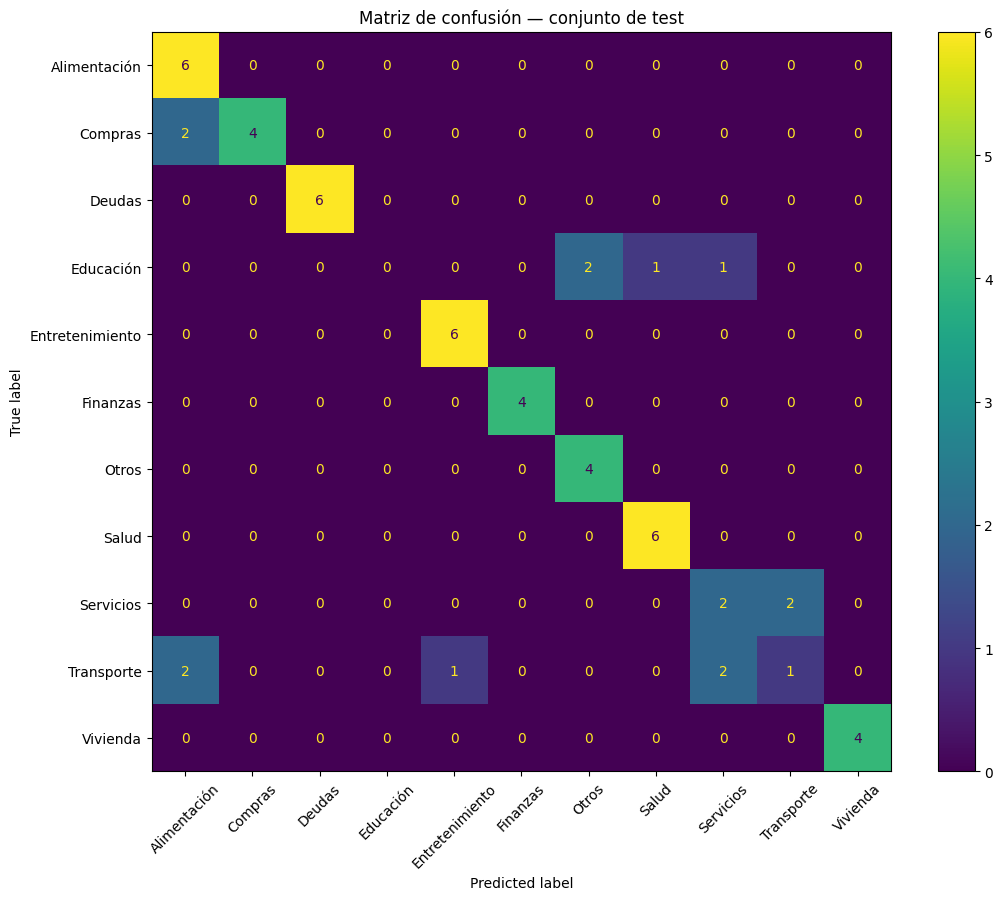

In [56]:
# Matriz de confusión

labels = sorted(y_test.unique())

confusion = confusion_matrix(y_test,test_prediction,labels=labels)
figure, axis = plt.subplots(figsize=(11, 9))
display_matrix = ConfusionMatrixDisplay(confusion_matrix=confusion,display_labels=labels)
display_matrix.plot(ax=axis,xticks_rotation=45,values_format="d")

plt.title("Matriz de confusión — conjunto de test")
plt.tight_layout()
plt.show()

## 8. Probabilidades y Top 3

Esta sección se ejecuta cuando el modelo seleccionado admite `predict_proba`. La precisión Top 3 considera correcta una predicción cuando la categoría real aparece entre las tres alternativas con mayor probabilidad

In [57]:
# ==============
# PROBABILIDADES
# ==============

if hasattr(selected_model, "predict_proba"):
    test_probabilities = selected_model.predict_proba(X_test)
    classes = selected_model.classes_
    test_metrics["top_3_accuracy"] = top_k_accuracy_score(y_test,test_probabilities,k=3,labels=classes)
    confidence = test_probabilities.max(axis=1)

    print("Top 3 accuracy:",round(test_metrics["top_3_accuracy"], 4))
    print("Confianza promedio:",round(confidence.mean(), 4))
else:
    test_probabilities = None
    classes = None
    confidence = np.full(len(X_test), np.nan)

    print("El modelo seleccionado no implementa predict_proba.")

Top 3 accuracy: 0.8214
Confianza promedio: 0.5884


## 9. Umbral de revisión manual

Una confianza baja no significa necesariamente que la predicción sea incorrecta, pero indica que el modelo está menos seguro

Para el MVP se calcula una tabla de cobertura:

- `cobertura`: porcentaje de movimientos aceptados automáticamente;
- `precision_aceptada`: precisión dentro de los movimientos que superan el umbral.

In [58]:
# =================
# TABLA DE UMBRALES
# =================

threshold_table = pd.DataFrame()

if test_probabilities is not None:
    correct_prediction = (test_prediction == y_test.to_numpy())
    threshold_rows = []

    for threshold in np.arange(0.35, 0.91, 0.05):
        accepted = confidence >= threshold

        threshold_rows.append({
            "umbral": round(float(threshold), 2),
            "cobertura": accepted.mean(),
            "registros_aceptados": accepted.sum(),
            "precision_aceptada": (correct_prediction[accepted].mean()
                if accepted.any()
                else np.nan
            )})

    threshold_table = pd.DataFrame(threshold_rows)
    display(threshold_table.round(4))

,umbral,cobertura,registros_aceptados,precision_aceptada
0,0.35,0.6786,38,0.8947
1,0.40,0.6607,37,0.8919
2,0.45,0.6071,34,0.9118
3,0.50,0.5357,30,0.9333
4,0.55,0.5357,30,0.9333
5,0.60,0.5179,29,0.9310
6,0.65,0.4821,27,0.9259
7,0.70,0.4821,27,0.9259
8,0.75,0.4286,24,0.9583
9,0.80,0.3750,21,1.0000


## 10. Análisis de errores

Es importante revisar qué frases fallan. Las métricas muestran cuánto falla el modelo; el análisis de errores ayuda a entender por qué.


In [59]:
# ====================
# PREDICCIONES DE TEST
# ====================

test_results_df = test_df[
    ["descripcion_modelo","descripcion_original","categoria","subcategoria","grupo_descripcion"]].copy()

test_results_df = test_results_df.rename(columns={"categoria": "categoria_real"})
test_results_df["categoria_predicha"] = test_prediction
test_results_df["confianza"] = confidence
test_results_df["es_correcta"] = (test_results_df["categoria_real"] == test_results_df["categoria_predicha"])
errors_df = test_results_df[~test_results_df["es_correcta"]].sort_values("confianza", ascending=False)

print("Errores encontrados:", len(errors_df))
display(errors_df)

Errores encontrados: 13


,descripcion_modelo,descripcion_original,categoria_real,subcategoria,grupo_descripcion,categoria_predicha,confianza,es_correcta
10,ropa en tienda,ropa en tienda,Compras,Ropa,ef15f6501962,Alimentación,0.789051,False
11,cargo ropa en tienda,ropa en tienda,Compras,Ropa,ef15f6501962,Alimentación,0.746459,False
20,Papelería,Papelería,Educación,Papelería,25d6432362f6,Otros,0.452067,False
21,cargo papelería,Papelería,Educación,Papelería,25d6432362f6,Otros,0.413135,False
50,pasaje de camión,pasaje de camión,Transporte,Autobús,c3deaa4d112d,Servicios,0.316842,False
44,servicio de televisión,servicio de televisión,Servicios,TV de paga,410d3807ecfd,Transporte,0.314118,False
18,libros de estudio,libros de estudio,Educación,Material escolar,1c5cf03667b7,Servicios,0.275297,False
45,serv de televisión,servicio de televisión,Servicios,TV de paga,410d3807ecfd,Transporte,0.209467,False
46,Combustible,Combustible,Transporte,Combustible,12c106cc092d,Alimentación,0.192658,False
51,cargo pasaje de camión,pasaje de camión,Transporte,Autobús,c3deaa4d112d,Servicios,0.183770,False


## 11. Diagnóstico de los errores de la versión 1

Antes de modificar el modelo, revisamos **qué categorías concentran los errores**.

La matriz de confusión y el reporte por clase mostraron que las categorías con mayor dificultad fueron:

- `Educación`
- `Servicios`
- `Transporte`

Lo que puede significar que el problema no está principalmente en el algoritmo, sino en la poca variedad lingüística de esas categorías.

In [60]:
# ==================================
# RESUMEN DE ERRORES DE LA VERSIÓN 1
# ==================================

errors_by_category_v1 = (errors_df.groupby(["categoria_real", "categoria_predicha"]).size().reset_index(name="errores").sort_values("errores", ascending=False))
category_performance_v1 = (report_df.loc[sorted(y_test.unique()),["precision", "recall", "f1-score", "support"]].sort_values("f1-score"))

print("Categorías con menor F1 en la versión 1:")
display(category_performance_v1.head(5).round(4))
print("Principales confusiones:")
display(errors_by_category_v1.head(10))

Categorías con menor F1 en la versión 1:


,precision,recall,f1-score,support
Educación,0.0000,0.0000,0.0000,4.0
Transporte,0.3333,0.1667,0.2222,6.0
Servicios,0.4000,0.5000,0.4444,4.0
Alimentación,0.6000,1.0000,0.7500,6.0
Compras,1.0000,0.6667,0.8000,6.0


Principales confusiones:


,categoria_real,categoria_predicha,errores
0,Compras,Alimentación,2
1,Educación,Otros,2
5,Transporte,Alimentación,2
4,Servicios,Transporte,2
7,Transporte,Servicios,2
2,Educación,Salud,1
3,Educación,Servicios,1
6,Transporte,Entretenimiento,1


In [61]:
# =====================================
# RECUPERAR LAS DESCRIPCIONES BASE
# =====================================

import hashlib
import random
import re
import unicodedata


def normalize_text(text):
    text = str(text).lower().strip()
    text = "".join(character for character in unicodedata.normalize("NFKD", text) if not unicodedata.combining(character))
    text = re.sub(r"[^a-z0-9ñ ]+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

base_v2_df = (data_df[["descripcion_original","categoria","subcategoria"]].drop_duplicates().rename(columns={"descripcion_original": "descripcion"}))
base_v2_df["texto_normalizado"] = (base_v2_df["descripcion"].apply(normalize_text))
base_v2_df = (base_v2_df.drop_duplicates(["texto_normalizado", "categoria"]).reset_index(drop=True))
print("Descripciones base recuperadas:", len(base_v2_df))

Descripciones base recuperadas: 186


## 13. Agregar ejemplos dirigidos

Los ejemplos nuevos se enfocan en vocabulario que el modelo debe reconocer claramente.

### Educación

- colegiatura;
- inscripción;
- semestre;
- cursos;
- libros y material escolar.

### Servicios

- luz;
- internet;
- teléfono;
- agua;
- gas;
- televisión.

### Transporte

- Uber y taxi;
- gasolina;
- autobús y tren;
- avión;
- mantenimiento vehicular.


In [63]:
EXTRA_EXAMPLES_V2 = {
    "Educación": [
        ("Universidad", "pago de colegiatura"),
        ("Universidad", "mensualidad universidad"),
        ("Universidad", "inscripción universitaria"),
        ("Universidad", "pago de semestre"),
        ("Universidad", "cuota escolar"),
        ("Cursos", "curso en udemy"),
        ("Cursos", "curso en coursera"),
        ("Cursos", "diplomado en línea"),
        ("Cursos", "capacitación profesional"),
        ("Cursos", "clase de inglés"),
        ("Cursos", "taller de programación"),
        ("Papelería", "compra en papelería"),
        ("Papelería", "útiles escolares"),
        ("Papelería", "cuadernos y plumas"),
        ("Material escolar", "libros escolares"),
        ("Material escolar", "material para clases"),
        ("Material escolar", "compra de libros de texto"),
        ("Material escolar", "uniforme escolar")
    ],
    "Servicios": [
        ("Electricidad", "pago recibo de luz"),
        ("Electricidad", "recibo cfe"),
        ("Electricidad", "servicio de electricidad"),
        ("Electricidad", "cargo de energía eléctrica"),
        ("Internet", "pago de internet"),
        ("Internet", "mensualidad de internet"),
        ("Internet", "servicio wifi casa"),
        ("Internet", "recibo de fibra óptica"),
        ("Teléfono", "pago del celular"),
        ("Teléfono", "plan de teléfono"),
        ("Teléfono", "recarga telefónica"),
        ("Teléfono", "mensualidad telcel"),
        ("Agua", "pago recibo del agua"),
        ("Agua", "servicio de agua potable"),
        ("Gas", "pago de gas doméstico"),
        ("Gas", "recarga de tanque de gas"),
        ("TV de paga", "pago de televisión por cable"),
        ("TV de paga", "mensualidad tv de paga")
    ],
    "Transporte": [
        ("Uber", "viaje en uber"),
        ("Uber", "uber al trabajo"),
        ("Uber", "uber al aeropuerto"),
        ("Taxi", "viaje en taxi"),
        ("Taxi", "taxi a casa"),
        ("Combustible", "carga de gasolina"),
        ("Combustible", "gasolina pemex"),
        ("Combustible", "llenado de tanque"),
        ("Combustible", "combustible para auto"),
        ("Autobús", "pasaje de autobús"),
        ("Autobús", "camión urbano"),
        ("Autobús", "boleto de autobús"),
        ("Tren", "boleto de metro"),
        ("Tren", "pasaje de tren"),
        ("Avión", "boleto de avión"),
        ("Avión", "vuelo nacional"),
        ("Servicio vehicular", "servicio del automóvil"),
        ("Servicio vehicular", "mantenimiento del coche"),
        ("Servicio vehicular", "taller mecánico"),
        ("Verificación vehicular", "verificación del auto"),
        ("Tenencia vehicular", "pago de tenencia")
    ],
    "Alimentación": [
        ("Supermercado", "compra de despensa"),
        ("Supermercado", "supermercado semanal"),
        ("Restaurante", "comida en restaurante"),
        ("Comida rápida", "pedido de comida rápida")
    ],
    "Compras": [
        ("Ropa", "compra de ropa"),
        ("Electrónica", "compra de audífonos"),
        ("Regalos", "regalo de cumpleaños"),
        ("Calzado", "compra de zapatos")
    ],
    "Otros": [
        ("Estacionamiento", "pago de estacionamiento"),
        ("Lavandería", "servicio de lavandería"),
        ("Donaciones", "donativo"),
        ("Otros", "gasto varios")
    ]}


extra_rows_v2 = []
for category, examples in EXTRA_EXAMPLES_V2.items():
    for subcategory, description in examples:
        extra_rows_v2.append({"descripcion": description,"categoria": category,"subcategoria": subcategory})

extra_v2_df = pd.DataFrame(extra_rows_v2)
extra_v2_df["texto_normalizado"] = (extra_v2_df["descripcion"].apply(normalize_text))
improved_base_df = pd.concat([base_v2_df, extra_v2_df], ignore_index=True)
improved_base_df = (improved_base_df.drop_duplicates(["texto_normalizado", "categoria"]).reset_index(drop=True))

# Eliminar frases con más de una categoría.
label_count_v2 = (improved_base_df.groupby("texto_normalizado")["categoria"].nunique())
ambiguous_texts_v2 = set(label_count_v2[label_count_v2 > 1].index)
improved_base_df = improved_base_df[~improved_base_df["texto_normalizado"].isin(ambiguous_texts_v2)].reset_index(drop=True)

print("Ejemplos dirigidos agregados:", len(extra_v2_df))
print("Descripciones base versión 2:", len(improved_base_df))
print("Textos ambiguos eliminados:", len(ambiguous_texts_v2))

Ejemplos dirigidos agregados: 69
Descripciones base versión 2: 245
Textos ambiguos eliminados: 0


In [64]:
# Comparar la cantidad de descripciones base

base_distribution_v1 = (base_v2_df.groupby("categoria").size())
base_distribution_v2 = (improved_base_df.groupby("categoria").size())
base_comparison = pd.DataFrame({"descripciones_base_v1": base_distribution_v1,"descripciones_base_v2": base_distribution_v2,}).fillna(0).astype(int)
base_comparison["incremento"] = (base_comparison["descripciones_base_v2"]- base_comparison["descripciones_base_v1"])
display(base_comparison.sort_values("incremento", ascending=False))

,descripciones_base_v1,descripciones_base_v2,incremento
categoria,,,
Educación,12,30,18
Transporte,19,37,18
Servicios,13,29,16
Alimentación,22,25,3
Otros,16,19,3
Compras,21,22,1
Deudas,17,17,0
Finanzas,11,11,0
Entretenimiento,19,19,0


## 14. Crear splits independientes

Se construyen nuevos splits porque el catálogo base cambió. La división se realiza dentro de cada categoría y por `grupo_descripcion`:

```text
70 % entrenamiento
15 % validación
15 % prueba
```

In [66]:
# =========================
# GRUPOS Y SPLITS VERSIÓN 2
# =========================

def create_group_id(row):
    value = (f"{row['categoria']}|"f"{row['texto_normalizado']}")
    return hashlib.sha1(value.encode("utf-8")).hexdigest()[:12]

improved_base_df["grupo_descripcion"] = (improved_base_df.apply(create_group_id,axis=1))

def assign_splits(base_data):
    assignments = {}
    for category, category_df in base_data.groupby("categoria"):
        group_ids = (category_df["grupo_descripcion"].tolist())
        category_seed = (SEED+ sum(ord(character)for character in category))
        local_random = random.Random(category_seed)
        local_random.shuffle(group_ids)
        total_groups = len(group_ids)
        test_count = max(1,round(total_groups * 0.15))
        validation_count = max(1,round(total_groups * 0.15))

        while (total_groups - test_count - validation_count < 2):
            if test_count > 1:test_count -= 1
            elif validation_count > 1:validation_count -= 1
            else:break

        for group_id in group_ids[:test_count]:assignments[group_id] = "test"
        for group_id in group_ids[test_count:test_count + validation_count]:assignments[group_id] = "validation"
        for group_id in group_ids[test_count + validation_count:]:assignments[group_id] = "train"
    return assignments

split_map_v2 = assign_splits(improved_base_df)
improved_base_df["split"] = (improved_base_df["grupo_descripcion"].map(split_map_v2))
display(improved_base_df.groupby(["categoria", "split"]).size().unstack(fill_value=0))

split,test,train,validation
categoria,,,
Alimentación,4,17,4
Compras,3,16,3
Deudas,3,11,3
Educación,4,22,4
Entretenimiento,3,13,3
Finanzas,2,7,2
Otros,3,13,3
Salud,3,16,3
Servicios,4,21,4


## 15. Aumento conservador

In [73]:
# ==========================
# AUMENTO DE TEXTO VERSIÓN 2
# ==========================

ABBREVIATIONS_V2 = {
    "transferencia": "transf",
    "mensualidad": "mens",
    "mensual": "mens",
    "tarjeta": "tdc",
    "credito": "cred",
    "crédito": "cred",
    "compra": "comp",
    "pago": "pg",
    "servicio": "serv",
    "universidad": "uni",
    "restaurante": "rest",
    "supermercado": "super",
    "mantenimiento": "mant",
    "estacionamiento": "estac",
    "inversion": "inv",
    "inversión": "inv",
    "prestamo": "prest",
    "préstamo": "prest",
}


def abbreviate_text(text):
    return " ".join(ABBREVIATIONS_V2.get(word, word)for word in text.lower().split())

def create_variants_v2(text, split):
    clean_text = " ".join(str(text).strip().split())
    if split != "train":return [clean_text]

    candidates = [clean_text,clean_text.lower(),normalize_text(clean_text),abbreviate_text(clean_text),f"cargo {clean_text.lower()}",f"{clean_text.lower()} mensual"]
    variants = []
    seen = set()

    for candidate in candidates:
        normalized_candidate = normalize_text(candidate)

        if (normalized_candidate and normalized_candidate not in seen):
            variants.append(candidate)
            seen.add(normalized_candidate)
        if len(variants) == 5:break
    return variants

dataset_v2_rows = []
for _, row in improved_base_df.iterrows():
    variants = create_variants_v2(row["descripcion"],row["split"])

    for variant in variants:
        dataset_v2_rows.append({
            "descripcion_modelo": variant,
            "descripcion_original": row["descripcion"],
            "categoria": row["categoria"],
            "subcategoria": row["subcategoria"],
            "split": row["split"],
            "grupo_descripcion": row["grupo_descripcion"],
            "texto_normalizado": normalize_text(variant),
            "es_aumentada": (variant != row["descripcion"])
        })


dataset_v2_df = pd.DataFrame(dataset_v2_rows)

# Eliminar posibles colisiones entre splits.
text_split_count_v2 = (dataset_v2_df.groupby("texto_normalizado")["split"].nunique())
collision_texts_v2 = set(text_split_count_v2[text_split_count_v2 > 1].index)
dataset_v2_df = dataset_v2_df[~dataset_v2_df["texto_normalizado"].isin(collision_texts_v2)].reset_index(drop=True)

print("Dimensiones versión 2:", dataset_v2_df.shape)
print("Colisiones eliminadas:", len(collision_texts_v2))
print()
print(dataset_v2_df["split"].value_counts())

Dimensiones versión 2: (641, 8)
Colisiones eliminadas: 2

split
train         569
test           36
validation     36
Name: count, dtype: int64


In [74]:
# ======================
# VALIDACIONES VERSIÓN 2
# ======================

validate(dataset_v2_df.isna().sum().sum() == 0,"El dataset v2 contiene valores nulos.")
validate(set(dataset_v2_df["split"])== {"train", "validation", "test"},"Los splits de v2 son incorrectos.")
validate(dataset_v2_df.groupby("grupo_descripcion")["split"].nunique().max()== 1,"Un grupo aparece en más de un split.")
validate(dataset_v2_df.groupby("texto_normalizado")["split"].nunique().max()== 1,"Un texto aparece en más de un split.")
categories_per_split_v2 = (dataset_v2_df.groupby("split")["categoria"].nunique())
validate(categories_per_split_v2.nunique() == 1,"No todos los splits tienen las mismas categorías.")
print("Validaciones de la versión 2 superadas.")

Validaciones de la versión 2 superadas.


## 16. Reentrenar los mismos modelos

In [76]:
# =========================
# CONJUNTOS DE LA VERSIÓN 2
# =========================

train_v2_df = dataset_v2_df[dataset_v2_df["split"] == "train"].copy()
validation_v2_df = dataset_v2_df[dataset_v2_df["split"] == "validation"].copy()
test_v2_df = dataset_v2_df[dataset_v2_df["split"] == "test"].copy()
X_train_v2 = train_v2_df["descripcion_modelo"]
y_train_v2 = train_v2_df["categoria"]
X_validation_v2 = (validation_v2_df["descripcion_modelo"])
y_validation_v2 = validation_v2_df["categoria"]
X_test_v2 = test_v2_df["descripcion_modelo"]
y_test_v2 = test_v2_df["categoria"]
models_v2 = {"Logistic Regression": LogisticRegression(max_iter=2000,class_weight="balanced",C=4.0,random_state=SEED),
             "Complement Naive Bayes": ComplementNB(alpha=0.5),"Linear SVM": LinearSVC(class_weight="balanced",C=1.0,random_state=SEED)}

trained_models_v2 = {}
comparison_v2_rows = []

for model_name, model in models_v2.items():
    pipeline = Pipeline([("features", create_tfidf_features()),("model", model)])

    pipeline.fit(X_train_v2,y_train_v2)
    validation_prediction_v2 = (pipeline.predict(X_validation_v2))
    comparison_v2_rows.append({
        "modelo": model_name,"accuracy_validation": accuracy_score(y_validation_v2,validation_prediction_v2),
        "precision_macro_validation": precision_score(y_validation_v2,validation_prediction_v2,average="macro",zero_division=0),
        "recall_macro_validation": recall_score(y_validation_v2,validation_prediction_v2,average="macro",zero_division=0),
        "f1_macro_validation": f1_score(y_validation_v2,validation_prediction_v2,average="macro",zero_division=0)
    })
    trained_models_v2[model_name] = pipeline


comparison_v2_df = (pd.DataFrame(comparison_v2_rows).sort_values("f1_macro_validation",ascending=False,).reset_index(drop=True))
display(comparison_v2_df.round(4))

,modelo,accuracy_validation,precision_macro_validation,recall_macro_validation,f1_macro_validation
0,Logistic Regression,0.8611,0.9080,0.8636,0.8637
1,Linear SVM,0.8611,0.9080,0.8636,0.8637
2,Complement Naive Bayes,0.8333,0.8626,0.8333,0.8365


## 17. Evaluar Regresión Logística en la versión 2


In [77]:
# ==============================
# TEST DE REGRESIÓN LOGÍSTICA V2
# ==============================

PRODUCT_MODEL = "Logistic Regression"

selected_model_v2 = (trained_models_v2[PRODUCT_MODEL])
test_prediction_v2 = selected_model_v2.predict(X_test_v2)
test_probabilities_v2 = (selected_model_v2.predict_proba(X_test_v2))
classes_v2 = selected_model_v2.classes_

test_metrics_v2 = {"accuracy": accuracy_score(y_test_v2,test_prediction_v2),
    "precision_macro": precision_score(y_test_v2,test_prediction_v2,average="macro",zero_division=0),
    "recall_macro": recall_score(y_test_v2,test_prediction_v2,average="macro",zero_division=0),
    "f1_macro": f1_score(y_test_v2,test_prediction_v2,average="macro",zero_division=0),
    "top_3_accuracy": top_k_accuracy_score(y_test_v2,test_probabilities_v2,k=3,labels=classes_v2)
}

display(pd.DataFrame([test_metrics_v2],index=["Logistic Regression v2"]).round(4))

,accuracy,precision_macro,recall_macro,f1_macro,top_3_accuracy
Logistic Regression v2,0.8611,0.8658,0.8712,0.8276,0.9444


In [78]:
# Reporte por categoría de la versión 2

report_v2_df = pd.DataFrame(classification_report(y_test_v2,test_prediction_v2,output_dict=True,zero_division=0,)).transpose()
display(report_v2_df.round(4))

,precision,recall,f1-score,support
Alimentación,1.0000,0.2500,0.4000,4.0000
Compras,0.7500,1.0000,0.8571,3.0000
Deudas,1.0000,1.0000,1.0000,3.0000
Educación,1.0000,1.0000,1.0000,4.0000
Entretenimiento,1.0000,0.6667,0.8000,3.0000
Finanzas,0.5000,1.0000,0.6667,1.0000
Otros,0.7500,1.0000,0.8571,3.0000
Salud,1.0000,0.6667,0.8000,3.0000
Servicios,1.0000,1.0000,1.0000,4.0000
Transporte,0.8571,1.0000,0.9231,6.0000


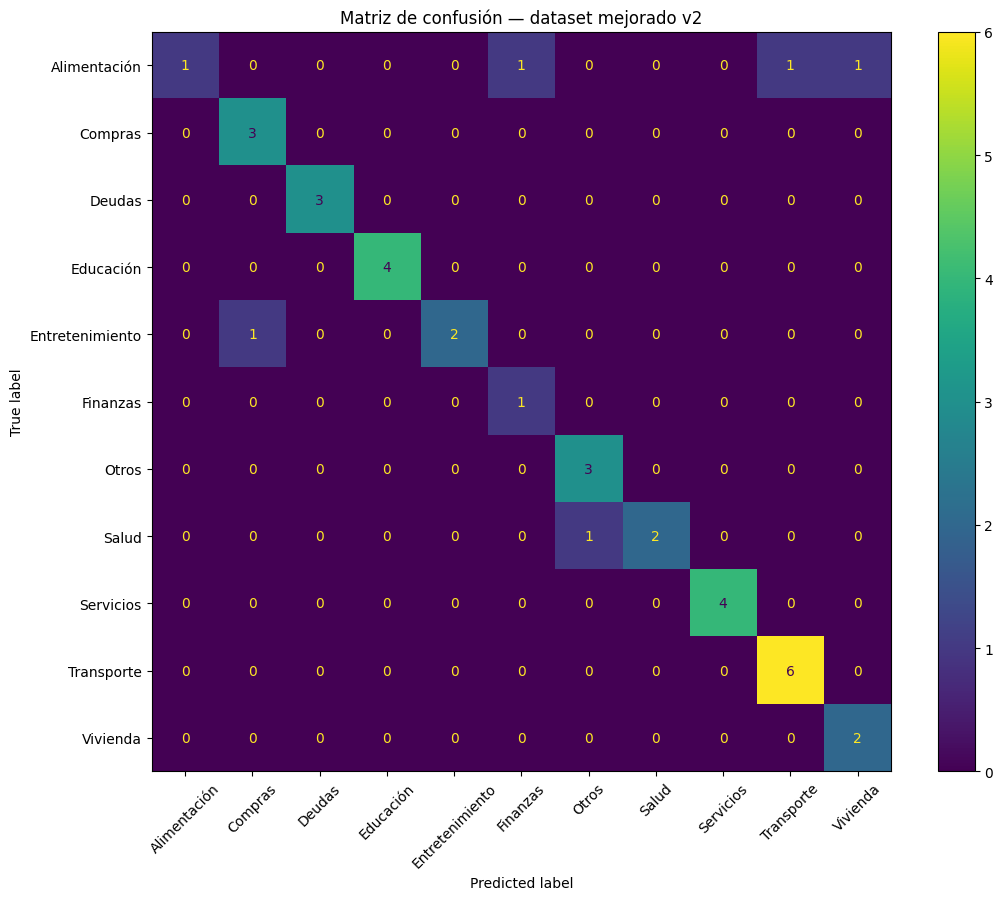

In [79]:
# Matriz de confusión de la versión 2

labels_v2 = sorted(y_test_v2.unique())
confusion_v2 = confusion_matrix(y_test_v2,test_prediction_v2,labels=labels_v2)
figure, axis = plt.subplots(figsize=(11, 9))
ConfusionMatrixDisplay(confusion_matrix=confusion_v2,display_labels=labels_v2).plot(ax=axis,xticks_rotation=45,values_format="d")

plt.title("Matriz de confusión — dataset mejorado v2")
plt.tight_layout()
plt.show()

## 18. Comparación antes y después

No deben compararse únicamente los valores globales. También debemos comprobar si mejoraron las categorías que originaron la intervención


In [80]:
# ============================
# MÉTRICAS GLOBALES V1 VS V2
# ============================

global_comparison = pd.DataFrame({
    "metrica": ["accuracy","precision_macro","recall_macro","f1_macro","top_3_accuracy"],
    "version_1": [
        test_metrics.get("accuracy", np.nan),
        test_metrics.get("precision_macro", np.nan),
        test_metrics.get("recall_macro", np.nan),
        test_metrics.get("f1_macro", np.nan),
        test_metrics.get("top_3_accuracy", np.nan),
    ],
    "version_2": [
        test_metrics_v2["accuracy"],
        test_metrics_v2["precision_macro"],
        test_metrics_v2["recall_macro"],
        test_metrics_v2["f1_macro"],
        test_metrics_v2["top_3_accuracy"],
    ]
})

global_comparison["diferencia"] = (global_comparison["version_2"] - global_comparison["version_1"])
display(global_comparison.round(4))

,metrica,version_1,version_2,diferencia
0,accuracy,0.7679,0.8611,0.0933
1,precision_macro,0.7013,0.8658,0.1645
2,recall_macro,0.7576,0.8712,0.1136
3,f1_macro,0.7148,0.8276,0.1128
4,top_3_accuracy,0.8214,0.9444,0.1230


In [81]:
# ==================================
# CATEGORÍAS CRÍTICAS V1 VS V2
# ==================================

critical_categories = ["Educación","Servicios","Transporte"]
critical_comparison_rows = []

for category in critical_categories:
    critical_comparison_rows.append({"categoria": category,"precision_v1": report_df.loc[category,"precision"],
        "precision_v2": report_v2_df.loc[category,"precision"],
        "recall_v1": report_df.loc[category,"recall"],
        "recall_v2": report_v2_df.loc[category,"recall"],
        "f1_v1": report_df.loc[category,"f1-score"],
        "f1_v2": report_v2_df.loc[category,"f1-score"]
    })


critical_comparison_df = pd.DataFrame(critical_comparison_rows)
critical_comparison_df["mejora_f1"] = (critical_comparison_df["f1_v2"]- critical_comparison_df["f1_v1"])
display(critical_comparison_df.round(4))

,categoria,precision_v1,precision_v2,recall_v1,recall_v2,f1_v1,f1_v2,mejora_f1
0,Educación,0.0000,1.0000,0.0000,1.0,0.0000,1.0000,1.0000
1,Servicios,0.4000,1.0000,0.5000,1.0,0.4444,1.0000,0.5556
2,Transporte,0.3333,0.8571,0.1667,1.0,0.2222,0.9231,0.7009


## 19. Análisis de errores de la versión 2

La mejora se considera útil cuando:

- Disminuyen los errores totales
- Sube el F1 macro
- Mejoran las categorías críticas
- Las nuevas confusiones siguen siendo razonables

In [82]:
# ============================
# ERRORES DE LA VERSIÓN 2
# ============================

test_results_v2_df = test_v2_df[
    [
        "descripcion_modelo",
        "descripcion_original",
        "categoria",
        "subcategoria",
        "grupo_descripcion",
    ]].copy()

test_results_v2_df = test_results_v2_df.rename(columns={"categoria": "categoria_real",})
test_results_v2_df["categoria_predicha"] = (test_prediction_v2)
test_results_v2_df["confianza"] = (test_probabilities_v2.max(axis=1))
test_results_v2_df["es_correcta"] = (test_results_v2_df["categoria_real"] == test_results_v2_df["categoria_predicha"])
errors_v2_df = test_results_v2_df[~test_results_v2_df["es_correcta"]].sort_values("confianza",ascending=False)

print("Errores versión 1:",len(errors_df))
print("Errores versión 2:",len(errors_v2_df))
display(errors_v2_df)

Errores versión 1: 13
Errores versión 2: 5


,descripcion_modelo,descripcion_original,categoria_real,subcategoria,grupo_descripcion,categoria_predicha,confianza,es_correcta
244,compra de videojuego,compra de videojuego,Entretenimiento,Videojuegos,d83b59cf4def,Compras,0.818685,False
115,despensa quincenal,despensa quincenal,Alimentación,Supermercado,cc529a2dbff3,Finanzas,0.351866,False
98,Almuerzo fuera de casa,Almuerzo fuera de casa,Alimentación,Restaurante,8ea97f3926e1,Vivienda,0.321881,False
336,Veterinario,Veterinario,Salud,Veterinario,adbf3c60a9b8,Otros,0.163397,False
75,Despensa,Despensa,Alimentación,Supermercado,1b32fa867fbb,Transporte,0.150485,False


## 20. Función de predicción final

La función utiliza el modelo mejorado y conserva el contrato esperado para FastAPI:

- Categoría
- Confianza
- Slternativas
- Revisión manual
- Versión del modelo


In [84]:
# ==============================
# FUNCIÓN FINAL PARA EL ENDPOINT
# ==============================

REVIEW_THRESHOLD_V2 = 0.60

def predict_category_v2(description, top_k=3):
    if not isinstance(description, str):raise TypeError("La descripción debe ser texto.")
    clean_description = description.strip()

    if not clean_description:raise ValueError("La descripción no puede estar vacía.")

    probabilities = (selected_model_v2.predict_proba([clean_description])[0])
    classes = selected_model_v2.classes_
    top_indices = np.argsort(probabilities)[::-1][:top_k]
    alternatives = [{"categoria": classes[index],"probabilidad": round(float(probabilities[index]),4)} for index in top_indices]
    confidence_value = float(probabilities[top_indices[0]])

    return {
        "descripcion": clean_description,
        "categoria_predicha": (classes[top_indices[0]]),
        "confianza": round(confidence_value,4),
        "requiere_revision": (confidence_value < REVIEW_THRESHOLD_V2),
        "alternativas": alternatives,
        "modelo_version": ("category-classifier-v2")
    }

examples_v2 = ["pago de colegiatura","recibo cfe","gasolina pemex","abono a tdc","transferencia a ahorro"]

for example in examples_v2:
    print(predict_category_v2(example))

{'descripcion': 'pago de colegiatura', 'categoria_predicha': 'Educación', 'confianza': 0.6966, 'requiere_revision': False, 'alternativas': [{'categoria': 'Educación', 'probabilidad': 0.6966}, {'categoria': 'Servicios', 'probabilidad': 0.0993}, {'categoria': 'Deudas', 'probabilidad': 0.0621}], 'modelo_version': 'category-classifier-v2'}
{'descripcion': 'recibo cfe', 'categoria_predicha': 'Servicios', 'confianza': 0.886, 'requiere_revision': False, 'alternativas': [{'categoria': 'Servicios', 'probabilidad': 0.886}, {'categoria': 'Educación', 'probabilidad': 0.0152}, {'categoria': 'Transporte', 'probabilidad': 0.0147}], 'modelo_version': 'category-classifier-v2'}
{'descripcion': 'gasolina pemex', 'categoria_predicha': 'Transporte', 'confianza': 0.8705, 'requiere_revision': False, 'alternativas': [{'categoria': 'Transporte', 'probabilidad': 0.8705}, {'categoria': 'Educación', 'probabilidad': 0.0188}, {'categoria': 'Otros', 'probabilidad': 0.0182}], 'modelo_version': 'category-classifier-v2

## 21. Entrenamiento final y exportación

- El pipeline final se entrena con `train + validation`
- Test se conserva fuera del entrenamiento para mantener una referencia independiente
- Se exportan ambas versiones de resultados para su documentación:

```text
problema detectado
        ↓
mejora del dataset
        ↓
reentrenamiento
        ↓
comparación
        ↓
modelo v2
```


In [88]:
# =============================
# ENTRENAMIENTO FINAL VERSIÓN 2
# =============================

train_validation_v2_df = dataset_v2_df[dataset_v2_df["split"].isin(["train", "validation"])].copy()

final_CategoryModel_v1 = Pipeline([("features", create_tfidf_features()),("model",LogisticRegression(max_iter=2000,class_weight="balanced",C=4.0,random_state=SEED))])
final_CategoryModel_v1.fit(train_validation_v2_df["descripcion_modelo"],train_validation_v2_df["categoria"])

print("Modelo v1 entrenado con:",len(train_validation_v2_df),"registros.")

Modelo v1 entrenado con: 605 registros.


In [91]:
# ==================
# EXPORTAR PRODUCTOS
# ==================

DATASET_PATH = (OUTPUT_DIR / "category_text_dataset_v1.csv")
MODEL_PATH = (OUTPUT_DIR / "category_classifier_v1.joblib")
PREDICTIONS_PATH = (OUTPUT_DIR/ "category_classifier_test_predictions_v1.csv")

dataset_v2_df.to_csv(DATASET_PATH,index=False,encoding="utf-8-sig")
joblib.dump(final_CategoryModel_v1,MODEL_PATH)
test_results_v2_df.to_csv(PREDICTIONS_PATH,index=False,encoding="utf-8-sig",)

print("Archivos generados:")
print(DATASET_PATH)
print(MODEL_PATH)
print(PREDICTIONS_PATH)

Archivos generados:
/content/category_text_dataset_v1.csv
/content/category_classifier_v1.joblib
/content/category_classifier_test_predictions_v1.csv


## Resultado final

Este notebook documenta el ciclo completo de mejora:

1. Se entrena una primera versión
2. Se evalúan métricas y matriz de confusión
3. Se localizan categorías débiles
4. Se plantea una hipótesis
5. Se mejora la cobertura lingüística
6. Se vuelve a entrenar con la misma metodología
7. Se comparan los resultados
8. Se exporta el modelo mejorado

El siguiente paso será integrar `category_classifier_v1.joblib` en el microservicio FastAPI